<a href="https://colab.research.google.com/github/hallaemilia/tinna-scheduler/blob/master/ex_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# For Colab users - install packages
%pip install -q evaluate sacrebleu bertviz sacremoses
%pip install -q wandb
%pip install torch

# For local users, these should already be installed via requirements.txt
# If running locally and packages are missing, uncomment the line above

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.4/139.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import torch
from tqdm import tqdm
import wandb
import json
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict


import evaluate
from datasets import load_dataset

from transformers import (
    AutoConfig,
    AutoModelForSeq2SeqLM,
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    MarianMTModel,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    set_seed
)

set_seed(42)

### Option 2

Switch from the original sinusoidal embeddings of Marian MT (absolute position encoding) to relative position encoding, as it may generalise better to longer sequence lengths. Specifically, use *strictly* one of T5-style learned relative position encoding, ALiBi, or RoPE.

*Hint*: There are various ways to implement this, some easier than others. You may use/adapt code from existing model implementations, but if you do, please note it in your report. You will need to re-train your model in order to get your modification to work.

## T5 IMPLEMENTATION

this below is the code that takes the MarianAttention class from modeling_marian.py (transformers) on github and creates a class with relatove position buckets and injects them into the model's forward pass, then the inject relative attention function just injects it into decoder and encoder layers.

In [3]:
import torch
from transformers.models.marian.modeling_marian import MarianAttention
from transformers.cache_utils import Cache, EncoderDecoderCache
import math
from typing import Optional, TypeVar, Unpack

T = TypeVar("T")

def get_relative_position_bucket(relative_position, bidirectional=True, num_buckets=32, max_distance=128):

    relative_buckets = 0
    if bidirectional:
        num_buckets //= 2
        relative_buckets = (relative_position > 0).to(torch.long) * num_buckets
        relative_position = torch.abs(relative_position)
    else:
        # Causal: only use negative positions (looking backward)
        # Clamp positive positions (future) to 0
        relative_position = -torch.min(relative_position, torch.zeros_like(relative_position))

    max_exact = num_buckets // 2
    is_small = relative_position < max_exact

    # For large distances, use logarithmic bucketing
    relative_position_if_large = max_exact + (
        torch.log(relative_position.float() / max_exact)
        / math.log(max_distance / max_exact)
        * (num_buckets - max_exact)
    ).to(torch.long)
    relative_position_if_large = torch.min(
        relative_position_if_large,
        torch.full_like(relative_position_if_large, num_buckets - 1)
    )

    relative_buckets += torch.where(is_small, relative_position, relative_position_if_large)
    return relative_buckets


class MarianRelativeAttention(MarianAttention):
    """
    MarianAttention with T5-style relative position embeddings.
    Only adds RPE to self-attention (encoder and decoder), not cross-attention.
    """

    def __init__(self, config, is_decoder=False, layer_idx: Optional[int] = None):
        embed_dim = config.d_model
        num_heads = config.decoder_attention_heads if is_decoder else config.encoder_attention_heads
        dropout = config.attention_dropout

        super().__init__(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            is_decoder=is_decoder,
            bias=True,
            is_causal=False,  # We handle causality ourselves via RPE
            config=config,
            layer_idx=layer_idx
        )

        self.is_decoder = is_decoder
        self.num_buckets = 32
        self.max_distance = 128

        # RPE bias embeddings
        self.relative_attention_bias = torch.nn.Embedding(self.num_buckets, self.num_heads)
        # Initialize with small values for stable training from scratch
        torch.nn.init.normal_(self.relative_attention_bias.weight, mean=0.0, std=0.02)

    def compute_bias(self, query_length, key_length, device, position_offset=0):

        context_position = torch.arange(
            query_length, dtype=torch.long, device=device
        )[:, None] + position_offset

        # Key positions: [0, 1, ..., key_length-1]
        memory_position = torch.arange(
            key_length, dtype=torch.long, device=device
        )[None, :]

        # Relative position: key_pos - query_pos
        # Negative = looking backward, Positive = looking forward
        relative_position = memory_position - context_position

        # For decoder self-attention, use unidirectional (causal) bucketing
        # For encoder self-attention, use bidirectional bucketing
        bidirectional = not self.is_decoder

        # Convert relative positions to bucket indices
        relative_position_bucket = get_relative_position_bucket(
            relative_position,
            bidirectional=bidirectional,
            num_buckets=self.num_buckets,
            max_distance=self.max_distance
        )

        # Look up bias values: (query_length, key_length, num_heads)
        values = self.relative_attention_bias(relative_position_bucket)

        # Permute to (num_heads, query_length, key_length)
        values = values.permute(2, 0, 1)

        return values

    def forward(
        self,
        hidden_states: torch.Tensor,
        key_value_states: Optional[torch.Tensor] = None,
        past_key_values: Optional[Cache] = None,
        attention_mask: Optional[torch.Tensor] = None,
        output_attentions: bool = False,
        cache_position: Optional[torch.Tensor] = None,
        **kwargs: Unpack[T],
    ):


        is_cross_attention = key_value_states is not None
        bsz, tgt_len = hidden_states.shape[:2]

        query_states = self.q_proj(hidden_states)
        query_states = query_states.view(bsz, tgt_len, self.num_heads, self.head_dim).transpose(1, 2)

        curr_past_key_values = past_key_values
        is_updated = False

        if isinstance(past_key_values, EncoderDecoderCache):
            if is_cross_attention:
                curr_past_key_values = past_key_values.cross_attention_cache
                is_updated = past_key_values.is_updated.get(self.layer_idx, False)
            else:
                curr_past_key_values = past_key_values.self_attention_cache

        current_states = key_value_states if is_cross_attention else hidden_states

        # For cross-attention, reuse cached encoder outputs if available
        if is_cross_attention and is_updated and curr_past_key_values is not None:
            cache_kwargs = {"cache_position": None}
            key_states, value_states = curr_past_key_values.update(
                None, None, self.layer_idx, cache_kwargs
            )
        else:
            # Compute new key/value projections
            key_states = self.k_proj(current_states)
            value_states = self.v_proj(current_states)
            key_states = key_states.view(bsz, -1, self.num_heads, self.head_dim).transpose(1, 2)
            value_states = value_states.view(bsz, -1, self.num_heads, self.head_dim).transpose(1, 2)

            # Update cache
            if curr_past_key_values is not None:
                cache_kwargs = {"cache_position": cache_position if not is_cross_attention else None}
                key_states, value_states = curr_past_key_values.update(
                    key_states, value_states, self.layer_idx, cache_kwargs
                )

                # Mark cross-attention cache as updated
                if is_cross_attention and isinstance(past_key_values, EncoderDecoderCache):
                    past_key_values.is_updated[self.layer_idx] = True

        # compute attention scores
        attn_weights = torch.matmul(query_states, key_states.transpose(-1, -2)) / math.sqrt(self.head_dim)

        # add rpe bias only to self attention
        if not is_cross_attention:
            query_length = query_states.shape[2]
            key_length = key_states.shape[2]

            # Determine position offset for generation
            if cache_position is not None and cache_position.numel() > 0:
                # During generation: queries start at position cache_position[0]
                position_offset = cache_position[0].item()
            else:
                # During training: queries start at position 0
                position_offset = 0

            # Compute and add RPE bias
            relative_bias = self.compute_bias(
                query_length=query_length,
                key_length=key_length,
                device=hidden_states.device,
                position_offset=position_offset
            )

            # Add bias: (num_heads, query_len, key_len) broadcasts to (bsz, num_heads, query_len, key_len)
            attn_weights = attn_weights + relative_bias.unsqueeze(0)
        if self.is_decoder and not is_cross_attention:
            # Create causal mask
            causal_mask = torch.triu(
                torch.ones(tgt_len, tgt_len, device=device) * float('-inf'),
                diagonal=1
            ).unsqueeze(0).unsqueeze(0)  # (1, 1, tgt_len, tgt_len)
            attn_weights = attn_weights + causal_mask


        # The attention_mask already contains causal masking for decoder self-attention
        if attention_mask is not None:
            attn_weights = attn_weights + attention_mask


        attn_weights = torch.nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)
        attn_probs = torch.nn.functional.dropout(attn_weights, p=self.dropout, training=self.training)

        attn_output = torch.matmul(attn_probs, value_states)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(bsz, tgt_len, self.embed_dim)
        attn_output = self.out_proj(attn_output)

        return attn_output, attn_weights if output_attentions else None


class ZeroPositionalEmbedding(torch.nn.Module):
    """Positional embedding stub that always returns zeros."""

    def __init__(self, embed_dim: int):
        super().__init__()
        self.embed_dim = embed_dim
        self.register_buffer("_zeros", torch.zeros(1, 1, embed_dim), persistent=False)

    def forward(
        self,
        input_shape: torch.Size,
        past_key_values_length: int = 0,
        position_ids: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        if isinstance(input_shape, torch.Size):
            batch_size, seq_len = input_shape[:2]
        else:
            batch_size, seq_len = input_shape
        return self._zeros.expand(batch_size, seq_len, -1)


def inject_relative_attention(model):

    # Replace sinusoidal positional embeddings with zeros so RPE drives the positional signal
    model.model.encoder.embed_positions = ZeroPositionalEmbedding(model.config.d_model)
    model.model.decoder.embed_positions = ZeroPositionalEmbedding(model.config.d_model)
    model.config.static_position_embeddings = False

    for i in range(model.config.encoder_layers):
        model.model.encoder.layers[i].self_attn = MarianRelativeAttention(
            config=model.config,
            is_decoder=False,
            layer_idx=i
        )

    for i in range(model.config.decoder_layers):
        model.model.decoder.layers[i].self_attn = MarianRelativeAttention(
            config=model.config,
            is_decoder=True,
            layer_idx=i
        )

    return model

In [4]:
from transformers import MarianMTModel, AutoConfig, AutoTokenizer

BASE_MODEL = "Helsinki-NLP/opus-mt-de-en"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
config = AutoConfig.from_pretrained(BASE_MODEL)

config.static_position_embeddings = False

model = MarianMTModel(config)
model = inject_relative_attention(model)

train_data = load_dataset("EdinburghNLP/europarl-de-en-mini", split="train") # we'll train on europarl sentences of length < 10.
valid_data = load_dataset("EdinburghNLP/europarl-de-en-mini", split="validation")
gen_data = load_dataset("EdinburghNLP/europarl-de-en-mini", split="gen_val") # length generalization data (length 10-20).

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

...

data/gen_test-00000-of-00001.parquet:   0%|          | 0.00/65.8k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/229170 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating gen_val split:   0%|          | 0/500 [00:00<?, ? examples/s]

Generating gen_test split:   0%|          | 0/500 [00:00<?, ? examples/s]

In [5]:
def create_preprocess_function(tokenizer):
  # global variables are bad! the preprocess function needs the tokenizer and the examples.
  def preprocess_function(examples):
      """Preprocess the data."""
      inputs = [ex["de"] for ex in examples["translation"]]
      targets = [ex["en"] for ex in examples["translation"]]
      model_inputs = tokenizer(
          inputs, text_target=targets, return_tensors="pt", padding=True
      )
      return model_inputs
  return preprocess_function

train_data = train_data.map(create_preprocess_function(tokenizer), batched=True)
valid_data = valid_data.map(create_preprocess_function(tokenizer), batched=True)
gen_data = gen_data.map(create_preprocess_function(tokenizer), batched=True)

Map:   0%|          | 0/229170 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [6]:
print(model)
for example in train_data[:10]['translation']:
    print(example)

MarianMTModel(
  (model): MarianModel(
    (shared): Embedding(58101, 512, padding_idx=58100)
    (encoder): MarianEncoder(
      (embed_tokens): Embedding(58101, 512, padding_idx=58100)
      (embed_positions): ZeroPositionalEmbedding()
      (layers): ModuleList(
        (0-5): 6 x MarianEncoderLayer(
          (self_attn): MarianRelativeAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
            (relative_attention_bias): Embedding(32, 8)
          )
          (self_attn_layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (activation_fn): SiLU()
          (fc1): Linear(in_features=512, out_features=2048, bias=True)
          (fc2): Linear(in_features=2048, out_features=512, bias=True)
          (fi

In [7]:
import os

NUM_EPOCHS = 5
BATCH_SIZE = 128
# os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_PROJECT"] = "anlp-assignment"  # name your W&B project

# Detect device for training configuration
use_mps = hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
use_cuda = torch.cuda.is_available()

# Set the device properly
if use_mps:
    device = torch.device("mps")
elif use_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

training_args = Seq2SeqTrainingArguments(
    learning_rate=5e-5,
    weight_decay=0.01,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    auto_find_batch_size=True,                # Adjust batch size automagically based on available memory
    output_dir='data/outputs',                # Specify where the model is saved
    save_total_limit=1,
    predict_with_generate=True,              # Do not calculate extrinsic metrics
    logging_steps=20,                         # Log metrics to WandB this often
    save_steps=500,                           # Save model this often
    eval_steps=500,                           # Evaluate model this often
    eval_strategy="steps",
    fp16=use_cuda,                           # Use half precision only for CUDA (not MPS)
    fp16_full_eval=use_cuda,                 # Use half precision during evaluation (CUDA only)
    group_by_length=True,                     # Group examples by length to minimise padding
    generation_max_length=20,                 # Maximum number of tokens generated
    report_to="wandb"                       # Report metrics to WandB if that helps...
)

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

# Initialize trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset={"val": valid_data, "gen": gen_data},
    data_collator=data_collator,
)

print(f"Training configuration:")
print(f"- Device: {device}")
print(f"- FP16: {use_cuda} (CUDA only)")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Epochs: {NUM_EPOCHS}")

Training configuration:
- Device: cuda
- FP16: True (CUDA only)
- Batch size: 128
- Epochs: 5


In [8]:
# # Clear memory before training
# if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
#     torch.mps.empty_cache()
#     print("Cleared MPS cache before training")

# Train the model
print("Starting training...")
trainer.train()

# Save the model
trainer.save_model()
print("Model saved successfully!")

Starting training...


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hallaemilia (hallaemilia-university-of-edinburgh) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Val Loss,Gen Loss
500,1.692900,No log,1.999266,2.816727
1000,1.435800,No log,1.717932,2.579344
1500,1.345800,No log,1.590106,2.498634
2000,1.247400,No log,1.498018,2.446291
2500,1.218700,No log,1.419815,2.418218
3000,1.123800,No log,1.358489,2.346147
3500,1.074400,No log,1.311708,2.350701
4000,1.084900,No log,1.272236,2.351908
4500,1.060300,No log,1.239248,2.348427
5000,1.011700,No log,1.209884,2.337196


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 512, 'num_beams': 4, 'bad_words_ids': [[58100]]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Model saved successfully!


In [42]:
!zip -r t5-de-en-nmt.zip


zip error: Nothing to do! (t5-de-en-nmt.zip)


## ANALYSIS FOR T5

In [ ]:
# Extract from trainer state in checkpoints
def extract_trainer_state():
    """Extract training metrics from trainer_state.json in checkpoints"""
    trainer_states = []

    # Check both checkpoint directories
    checkpoint_dirs = [
        "data/t5-de-en-nmt/checkpoint-8955"
    ]

    for checkpoint_dir in checkpoint_dirs:
        trainer_state_path = os.path.join(checkpoint_dir, "trainer_state.json")
        if os.path.exists(trainer_state_path):
            with open(trainer_state_path, 'r') as f:
                state = json.load(f)
                trainer_states = state["log_history"]
                print(f"Found trainer state in {checkpoint_dir}")

    return trainer_states

# First, try trainer state method (most reliable)
trainer_states = extract_trainer_state()
print(trainer_states[0])

Found trainer state in data/t5-de-en-nmt/checkpoint-8955
{'epoch': 0.011166945840312675, 'grad_norm': 12.747123718261719, 'learning_rate': 4.989391401451703e-05, 'loss': 10.3545, 'step': 20}


Then we plot the data based on the ```trainer_states``` stats

Available columns in training log:
['epoch', 'grad_norm', 'learning_rate', 'loss', 'step', 'eval_val_loss', 'eval_val_runtime', 'eval_val_samples_per_second', 'eval_val_steps_per_second', 'eval_gen_loss', 'eval_gen_runtime', 'eval_gen_samples_per_second', 'eval_gen_steps_per_second']

Number of logged steps: 457

Required losses: ['loss', 'eval_val_loss', 'eval_gen_loss']
Available losses: ['loss', 'eval_val_loss', 'eval_gen_loss']

All three loss types found - proceeding with complete plot
Training Loss: 423 data points
I.I.D. Validation Loss (< 10 words): 17 data points
O.O.D. Validation Loss (10-20 words): 17 data points


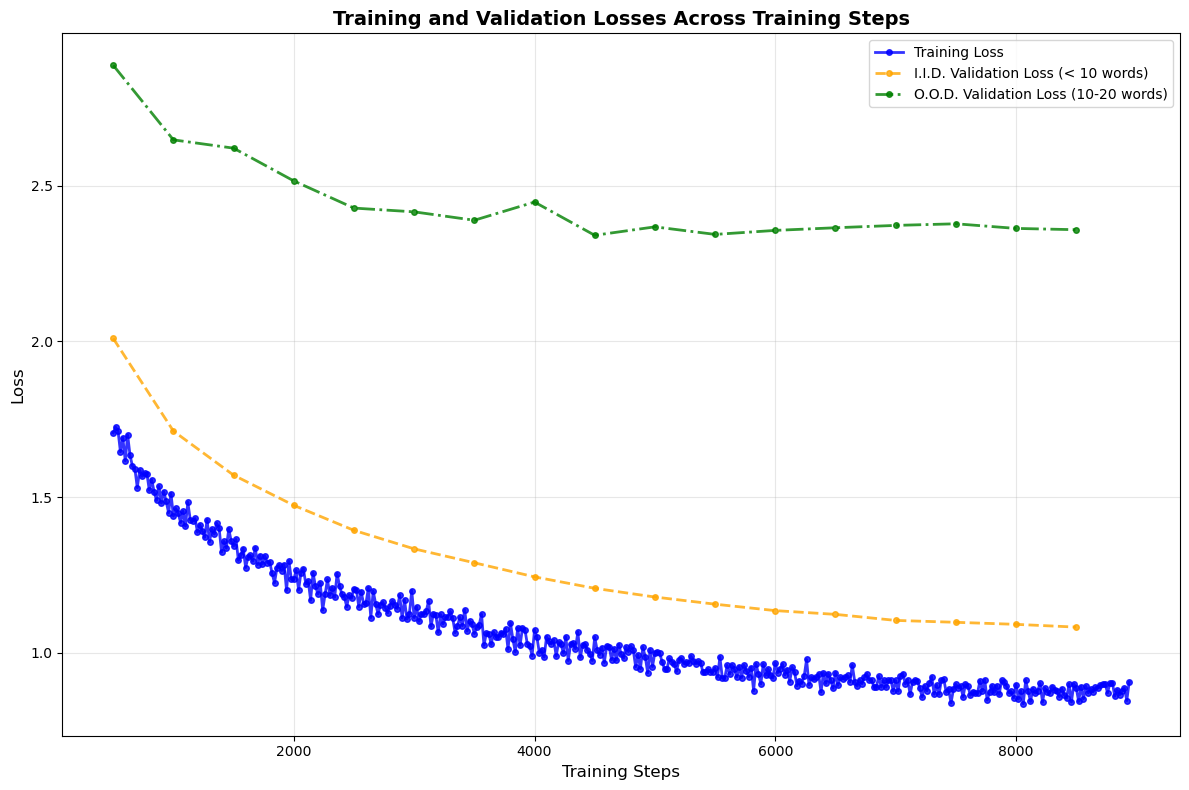


LOSS ANALYSIS SUMMARY

Training Loss:
  Initial loss: 1.7061
  Final loss:   0.9064
  Reduction:    0.7997 (46.9%)
  Minimum:      0.8364
  Maximum:      1.7244

I.I.D. Validation Loss (< 10 words):
  Initial loss: 2.0094
  Final loss:   1.0826
  Reduction:    0.9268 (46.1%)
  Minimum:      1.0826
  Maximum:      2.0094

O.O.D. Validation Loss (10-20 words):
  Initial loss: 2.8862
  Final loss:   2.3583
  Reduction:    0.5279 (18.3%)
  Minimum:      2.3404
  Maximum:      2.8862

------------------------------------------------------------
GENERALIZATION ANALYSIS
------------------------------------------------------------
Final I.I.D. validation loss:     1.0826
Final O.O.D. validation loss:     2.3583
Generalization gap (O.O.D - I.I.D): 1.2757
Relative increase: 117.8%


In [ ]:
# Convert trainer_states to DataFrame and plot all three losses
df = pd.DataFrame(trainer_states)

# Start at 500 to skip initial noisy logs
df = df[df['step'] >= 500]

print("Available columns in training log:")
print(df.columns.tolist())
print(f"\nNumber of logged steps: {len(df)}")

# Check if we have all three loss types before plotting
required_losses = ['loss', 'eval_val_loss', 'eval_gen_loss']
available_losses = [loss for loss in required_losses if loss in df.columns and not df[loss].isna().all()]

print(f"\nRequired losses: {required_losses}")
print(f"Available losses: {available_losses}")

if len(available_losses) == 3:
    print("\nAll three loss types found - proceeding with complete plot")

    # Create the plot
    plt.figure(figsize=(12, 8))

    # Define the metrics and their labels
    metrics_info = [
        ('loss', 'Training Loss', 'blue', '-'),
        ('eval_val_loss', 'I.I.D. Validation Loss (< 10 words)', 'orange', '--'),
        ('eval_gen_loss', 'O.O.D. Validation Loss (10-20 words)', 'green', '-.')
    ]

    # Plot each metric
    for metric, label, color, linestyle in metrics_info:
        if metric in df.columns:
            # Filter out NaN values
            metric_data = df[df[metric].notna()]
            if not metric_data.empty:
                plt.plot(metric_data['step'], metric_data[metric],
                       label=label, color=color, linestyle=linestyle,
                       linewidth=2, marker='o', markersize=4, alpha=0.8)
                print(f"{label}: {len(metric_data)} data points")

    plt.xlabel('Training Steps', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Training and Validation Losses Across Training Steps', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('report/figures/t5rpe_loss_analysis.png', dpi=300)
    plt.show()

    # Print detailed statistics
    print("\n" + "="*60)
    print("LOSS ANALYSIS SUMMARY")
    print("="*60)

    for metric, label, _, _ in metrics_info:
        if metric in df.columns:
            metric_data = df[df[metric].notna()][metric]
            if not metric_data.empty:
                print(f"\n{label}:")
                print(f"  Initial loss: {metric_data.iloc[0]:.4f}")
                print(f"  Final loss:   {metric_data.iloc[-1]:.4f}")
                print(f"  Reduction:    {metric_data.iloc[0] - metric_data.iloc[-1]:.4f} ({((metric_data.iloc[0] - metric_data.iloc[-1])/metric_data.iloc[0]*100):.1f}%)")
                print(f"  Minimum:      {metric_data.min():.4f}")
                print(f"  Maximum:      {metric_data.max():.4f}")

    # Show the relationship between splits
    print(f"\n" + "-"*60)
    print("GENERALIZATION ANALYSIS")
    print("-"*60)

    if 'eval_val_loss' in df.columns and 'eval_gen_loss' in df.columns:
        val_final = df[df['eval_val_loss'].notna()]['eval_val_loss'].iloc[-1]
        gen_final = df[df['eval_gen_loss'].notna()]['eval_gen_loss'].iloc[-1]
        generalization_gap = gen_final - val_final

        print(f"Final I.I.D. validation loss:     {val_final:.4f}")
        print(f"Final O.O.D. validation loss:     {gen_final:.4f}")
        print(f"Generalization gap (O.O.D - I.I.D): {generalization_gap:.4f}")
        print(f"Relative increase: {(generalization_gap/val_final*100):.1f}%")

else:
    print(f"\nWarning: Not all three loss types are available.")
    print(f"Missing: {set(required_losses) - set(available_losses)}")
    print("Skipping plot generation to ensure complete comparison.")
    print("\nTo generate the plot, make sure your training data contains:")
    print("- 'loss' (training loss)")
    print("- 'eval_val_loss' (i.i.d. validation loss)")
    print("- 'eval_gen_loss' (o.o.d. validation loss)")

    # Still show what data we do have
    print(f"\nAvailable data preview:")
    for loss in available_losses:
        loss_data = df[df[loss].notna()][loss]
        if not loss_data.empty:
            print(f"{loss}: {len(loss_data)} data points, range [{loss_data.min():.4f}, {loss_data.max():.4f}]")

In [ ]:
BATCH_SIZE = 1

def eval(dataset, model, gen_config=None, metrics=None):
    """
    dataset is one of the two splits: valid_data, gen_data
    model is one of the two models: yours or pretrained
    gen_config is a dictionary of arguments for model.generate()
    metrics is a dictionary of functions to compute metrics
    """

    results = []

    if gen_config is None:
        gen_config = {
            "max_length": 20,
            "num_beams": 4,
            "early_stopping": True,
        }

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = model.to(device)
    model.eval()

    all_predictions = []
    all_labels = []

    for batch in tqdm(dataset.batch(BATCH_SIZE)):
        # Move inputs to device
        inputs = tokenizer(
            [ex["de"] for ex in batch["translation"]],
            return_tensors="pt",
            padding=True,
            truncation=True
        ).to(device)

        # Generate translations
        with torch.no_grad():
            generated_tokens = model.generate(
                inputs["input_ids"],
                attention_mask=inputs["attention_mask"],
                **gen_config
            )

        # Decode translations
        translations = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)


        for i in range(len(translations)):
            all_predictions.append(translations[i])
            all_labels.append(batch['translation'][i]['en'])

            example_metrics = {
                    "input": batch["translation"][i]["de"],
                    "prediction": translations[i],
                    "reference": batch["translation"][i]["en"],
                }

            results.append(
                example_metrics
            )

    global_metrics = {}
    if metrics is not None:
        for metric_name, metric_func in metrics.items():
            global_metrics[metric_name] = metric_func(all_predictions, all_labels)

    return results, global_metrics

In [ ]:
from pathlib import Path

try:
    from safetensors.torch import load_file as load_safetensors
except ImportError:
    load_safetensors = None


def load_rpe_marian(path, map_location="cpu"):
    """Load a Marian checkpoint trained with T5-style relative attention."""

    def _has_weights(directory: Path) -> bool:
        return any((directory / name).exists() for name in ("pytorch_model.bin", "model.safetensors"))

    checkpoint_dir = Path(path)
    if not checkpoint_dir.exists():
        raise FileNotFoundError(f"Checkpoint directory {checkpoint_dir} does not exist")

    if not _has_weights(checkpoint_dir):
        checkpoints = sorted(
            [d for d in checkpoint_dir.glob("checkpoint-*") if d.is_dir()],
            key=lambda p: int(p.name.split("-")[-1]) if p.name.split("-")[-1].isdigit() else -1,
            reverse=True,
        )
        for candidate in checkpoints:
            if _has_weights(candidate):
                checkpoint_dir = candidate
                break
        else:
            raise FileNotFoundError(
                f"No model weights found in {checkpoint_dir} or its checkpoint-* subdirectories"
            )


    config = AutoConfig.from_pretrained(checkpoint_dir)
    model = MarianMTModel(config)
    model = inject_relative_attention(model)

    bin_path = checkpoint_dir / "pytorch_model.bin"
    safetensors_path = checkpoint_dir / "model.safetensors"

    if bin_path.exists():
        state = torch.load(bin_path, map_location=map_location)
    elif safetensors_path.exists():
        if load_safetensors is None:
            raise ImportError(
                "safetensors is required to load model.safetensors; install it or save a pytorch_model.bin"
            )
        state = load_safetensors(str(safetensors_path))
    else:
        raise FileNotFoundError(
            f"No pytorch_model.bin or model.safetensors found in {checkpoint_dir}"
        )

    incompatible = model.load_state_dict(state, strict=False)

    ignored_missing = set(getattr(model, "_tied_weights_keys", []))
    keys_to_ignore = getattr(model, "_keys_to_ignore_on_load_missing", [])
    base_prefix = getattr(model, "base_model_prefix", None)

    for key in keys_to_ignore:
        ignored_missing.add(key)
        if base_prefix and not key.startswith(f"{base_prefix}."):
            ignored_missing.add(f"{base_prefix}.{key}")

    missing = [key for key in incompatible.missing_keys if key not in ignored_missing]
    unexpected = list(incompatible.unexpected_keys)

    if missing or unexpected:
        messages = []
        if missing:
            messages.append(f"Missing keys: {missing}")
        if unexpected:
            messages.append(f"Unexpected keys: {unexpected}")
        raise RuntimeError("Error loading relative-attention Marian checkpoint: " + "; ".join(messages))

    model.tie_weights()
    return model


In [ ]:
models = {"t5": "data/t5-de-en-nmt", "my": "data/my-de-en-nmt", "pretrained": "Helsinki-NLP/opus-mt-de-en"}
datasets = {"i.i.d.": valid_data, "o.o.d.": gen_data}
metrics = {}

# For now, we use the default generation configuration and do not evaluate metrics
# This is just to obtain the model translations
all_results = {}
for a, model_name in models.items():
    if a == "t5":
        model = load_rpe_marian("data/t5-de-en-nmt")
    else:
        model = AutoModelForSeq2SeqLM.from_pretrained(model_name, attn_implementation='eager')

    for b, dataset in datasets.items():
        print(f"Evaluating {a} model on {b} split")
        results, global_metrics = eval(dataset, model, metrics=metrics)
        all_results[f"{a} {b}"] = results

Evaluating t5 model on i.i.d. split


  4%|▍         | 22/500 [00:03<01:03,  7.48it/s]

In [ ]:
for title, results in all_results.items():
    print(f"--- {title} ---")
    results_df = pd.DataFrame(results)

    # Filter for examples with at least 5 words in the input
    results_df_filtered = results_df[results_df['input'].str.split().str.len() >= 5].reset_index()

    print("\nFirst 25 translations:")
    # Check if there are enough examples after filtering
    if len(results_df_filtered) >= 25:
        for index, row in results_df_filtered.head(25).iterrows():
            print("Index:", index)
            print(f"Input: {row['input']}")
            print(f"Prediction: {row['prediction']}")
            print(f"Reference: {row['reference']}\n")

--- t5 i.i.d. ---

First 25 translations:
Index: 0
Input: Europa verfügt über ein großes Potenzial an erneuerbarer Energie.
Prediction: Europe has a great great deal of energy.
Reference: In Europe, we have a vast renewable energy potential.

Index: 1
Input: Kommissar Verheugen stimmte dieser Forderung bei der gestrigen Aussprache zu.
Prediction: Commissioner Verheugen supports this debate on yesterday.
Reference: Commissioner Verheugen endorsed this demand during yesterday's debate.

Index: 2
Input: Welcher Empfang wird diesen Menschen bereitet?
Prediction: What are these people going to do?
Reference: What reception will be given to these people?

Index: 3
Input: Alle Ausnahmen werden mit einer Mehrheit von 75 % beschlossen.
Prediction: Everyone will have a majority with a majority of jobs.
Reference: Any exceptions shall be approved with 75 % support.

Index: 4
Input: Ihr solltet dasselbe tun wie wir!'
Prediction: You should do the same as we do.'
Reference: You should do as we have

this below is the code that takes the MarianAttention class from modeling_marian.py (transformers) on github and creates a class with relatove position buckets and injects them into the model's forward pass, then the inject relative attention function just injects it into decoder and encoder layers.

THE PROBLEMS WE'RE FACING RIGHT NOW:
1. there might be caching issue
2. very low valid and gen loss, i think tokens are sseing into the future lol
3. generation just generates ........... or ssssssssss
4. might have problems with the decoder layer or casual masking in it

In [ ]:
import torch
from transformers.models.marian.modeling_marian import MarianAttention
from transformers.cache_utils import Cache, EncoderDecoderCache
import math
from typing import Optional, TypeVar, Unpack

T = TypeVar("T")

def get_relative_position_bucket(relative_position, bidirectional=True, num_buckets=32, max_distance=128):

    relative_buckets = 0
    if bidirectional:
        num_buckets //= 2
        relative_buckets = (relative_position > 0).to(torch.long) * num_buckets
        relative_position = torch.abs(relative_position)
    else:
        # Causal: only use negative positions (looking backward)
        # Clamp positive positions (future) to 0
        relative_position = -torch.min(relative_position, torch.zeros_like(relative_position))

    max_exact = num_buckets // 2
    is_small = relative_position < max_exact

    # For large distances, use logarithmic bucketing
    relative_position_if_large = max_exact + (
        torch.log(relative_position.float() / max_exact)
        / math.log(max_distance / max_exact)
        * (num_buckets - max_exact)
    ).to(torch.long)
    relative_position_if_large = torch.min(
        relative_position_if_large,
        torch.full_like(relative_position_if_large, num_buckets - 1)
    )

    relative_buckets += torch.where(is_small, relative_position, relative_position_if_large)
    return relative_buckets


class MarianRelativeAttention(MarianAttention):
    """
    MarianAttention with T5-style relative position embeddings.
    Only adds RPE to self-attention (encoder and decoder), not cross-attention.
    """

    def __init__(self, config, is_decoder=False, layer_idx: Optional[int] = None):
        embed_dim = config.d_model
        num_heads = config.decoder_attention_heads if is_decoder else config.encoder_attention_heads
        dropout = config.attention_dropout

        super().__init__(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            is_decoder=is_decoder,
            bias=True,
            is_causal=False,  # We handle causality ourselves via RPE
            config=config,
            layer_idx=layer_idx
        )

        self.is_decoder = is_decoder
        self.num_buckets = 32
        self.max_distance = 128

        # RPE bias embeddings
        self.relative_attention_bias = torch.nn.Embedding(self.num_buckets, self.num_heads)
        # Initialize with small values for stable training from scratch
        torch.nn.init.normal_(self.relative_attention_bias.weight, mean=0.0, std=0.02)

    def compute_bias(self, query_length, key_length, device, position_offset=0):

        context_position = torch.arange(
            query_length, dtype=torch.long, device=device
        )[:, None] + position_offset

        # Key positions: [0, 1, ..., key_length-1]
        memory_position = torch.arange(
            key_length, dtype=torch.long, device=device
        )[None, :]

        # Relative position: key_pos - query_pos
        # Negative = looking backward, Positive = looking forward
        relative_position = memory_position - context_position

        # For decoder self-attention, use unidirectional (causal) bucketing
        # For encoder self-attention, use bidirectional bucketing
        bidirectional = not self.is_decoder

        # Convert relative positions to bucket indices
        relative_position_bucket = get_relative_position_bucket(
            relative_position,
            bidirectional=bidirectional,
            num_buckets=self.num_buckets,
            max_distance=self.max_distance
        )

        # Look up bias values: (query_length, key_length, num_heads)
        values = self.relative_attention_bias(relative_position_bucket)

        # Permute to (num_heads, query_length, key_length)
        values = values.permute(2, 0, 1)

        return values

    def forward(
        self,
        hidden_states: torch.Tensor,
        key_value_states: Optional[torch.Tensor] = None,
        past_key_values: Optional[Cache] = None,
        attention_mask: Optional[torch.Tensor] = None,
        output_attentions: bool = False,
        cache_position: Optional[torch.Tensor] = None,
        **kwargs: Unpack[T],
    ):


        is_cross_attention = key_value_states is not None
        bsz, tgt_len = hidden_states.shape[:2]

        query_states = self.q_proj(hidden_states)
        query_states = query_states.view(bsz, tgt_len, self.num_heads, self.head_dim).transpose(1, 2)

        curr_past_key_values = past_key_values
        is_updated = False

        if isinstance(past_key_values, EncoderDecoderCache):
            if is_cross_attention:
                curr_past_key_values = past_key_values.cross_attention_cache
                is_updated = past_key_values.is_updated.get(self.layer_idx, False)
            else:
                curr_past_key_values = past_key_values.self_attention_cache

        current_states = key_value_states if is_cross_attention else hidden_states

        # For cross-attention, reuse cached encoder outputs if available
        if is_cross_attention and is_updated and curr_past_key_values is not None:
            cache_kwargs = {"cache_position": None}
            key_states, value_states = curr_past_key_values.update(
                None, None, self.layer_idx, cache_kwargs
            )
        else:
            # Compute new key/value projections
            key_states = self.k_proj(current_states)
            value_states = self.v_proj(current_states)
            key_states = key_states.view(bsz, -1, self.num_heads, self.head_dim).transpose(1, 2)
            value_states = value_states.view(bsz, -1, self.num_heads, self.head_dim).transpose(1, 2)

            # Update cache
            if curr_past_key_values is not None:
                cache_kwargs = {"cache_position": cache_position if not is_cross_attention else None}
                key_states, value_states = curr_past_key_values.update(
                    key_states, value_states, self.layer_idx, cache_kwargs
                )

                # Mark cross-attention cache as updated
                if is_cross_attention and isinstance(past_key_values, EncoderDecoderCache):
                    past_key_values.is_updated[self.layer_idx] = True

        # compute attention scores
        attn_weights = torch.matmul(query_states, key_states.transpose(-1, -2)) / math.sqrt(self.head_dim)

        # add rpe bias only to self attention
        if not is_cross_attention:
            query_length = query_states.shape[2]
            key_length = key_states.shape[2]

            # Determine position offset for generation
            if cache_position is not None and cache_position.numel() > 0:
                # During generation: queries start at position cache_position[0]
                position_offset = cache_position[0].item()
            else:
                # During training: queries start at position 0
                position_offset = 0

            # Compute and add RPE bias
            relative_bias = self.compute_bias(
                query_length=query_length,
                key_length=key_length,
                device=hidden_states.device,
                position_offset=position_offset
            )

            # Add bias: (num_heads, query_len, key_len) broadcasts to (bsz, num_heads, query_len, key_len)
            attn_weights = attn_weights + relative_bias.unsqueeze(0)
        if self.is_decoder and not is_cross_attention:
            # Create causal mask
            causal_mask = torch.triu(
                torch.ones(tgt_len, tgt_len, device=device) * float('-inf'),
                diagonal=1
            ).unsqueeze(0).unsqueeze(0)  # (1, 1, tgt_len, tgt_len)
            attn_weights = attn_weights + causal_mask


        # The attention_mask already contains causal masking for decoder self-attention
        if attention_mask is not None:
            attn_weights = attn_weights + attention_mask


        attn_weights = torch.nn.functional.softmax(attn_weights, dim=-1, dtype=torch.float32).to(query_states.dtype)
        attn_probs = torch.nn.functional.dropout(attn_weights, p=self.dropout, training=self.training)

        attn_output = torch.matmul(attn_probs, value_states)
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.reshape(bsz, tgt_len, self.embed_dim)
        attn_output = self.out_proj(attn_output)

        return attn_output, attn_weights if output_attentions else None


def inject_relative_attention(model):

    for i in range(model.config.encoder_layers):
        model.model.encoder.layers[i].self_attn = MarianRelativeAttention(
            config=model.config,
            is_decoder=False,
            layer_idx=i
        )

    # Replace decoder self-attention (not cross-attention)
    for i in range(model.config.decoder_layers):
        model.model.decoder.layers[i].self_attn = MarianRelativeAttention(
            config=model.config,
            is_decoder=True,
            layer_idx=i
        )

    return model

In [ ]:
from transformers import MarianMTModel, AutoConfig, AutoTokenizer

BASE_MODEL = "Helsinki-NLP/opus-mt-de-en"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
config = AutoConfig.from_pretrained(BASE_MODEL)

model = MarianMTModel(config)
model = inject_relative_attention(model)

train_data = load_dataset("EdinburghNLP/europarl-de-en-mini", split="train") # we'll train on europarl sentences of length < 10.
valid_data = load_dataset("EdinburghNLP/europarl-de-en-mini", split="validation")
gen_data = load_dataset("EdinburghNLP/europarl-de-en-mini", split="gen_val") # length generalization data (length 10-20).

In [ ]:
def create_preprocess_function(tokenizer):
  # global variables are bad! the preprocess function needs the tokenizer and the examples.
  def preprocess_function(examples):
      """Preprocess the data."""
      inputs = [ex["de"] for ex in examples["translation"]]
      targets = [ex["en"] for ex in examples["translation"]]
      model_inputs = tokenizer(
          inputs, text_target=targets, return_tensors="pt", padding=True
      )
      return model_inputs
  return preprocess_function

train_data = train_data.map(create_preprocess_function(tokenizer), batched=True)
valid_data = valid_data.map(create_preprocess_function(tokenizer), batched=True)
gen_data = gen_data.map(create_preprocess_function(tokenizer), batched=True)

In [ ]:
import os

NUM_EPOCHS = 5
BATCH_SIZE = 128
os.environ["WANDB_DISABLED"] = "true"
# os.environ["WANDB_PROJECT"] = "anlp-assignment"  # name your W&B project

# Detect device for training configuration
use_mps = hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
use_cuda = torch.cuda.is_available()

# Set the device properly
if use_mps:
    device = torch.device("mps")
elif use_cuda:
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

training_args = Seq2SeqTrainingArguments(
    learning_rate=5e-5,
    weight_decay=0.01,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    auto_find_batch_size=True,                # Adjust batch size automagically based on available memory
    output_dir='data/outputs',                # Specify where the model is saved
    save_total_limit=1,
    predict_with_generate=False,              # Do not calculate extrinsic metrics
    logging_steps=20,                         # Log metrics to WandB this often
    save_steps=500,                           # Save model this often
    eval_steps=500,                           # Evaluate model this often
    eval_strategy="steps",
    fp16=use_cuda,                           # Use half precision only for CUDA (not MPS)
    fp16_full_eval=use_cuda,                 # Use half precision during evaluation (CUDA only)
    group_by_length=True,                     # Group examples by length to minimise padding
    generation_max_length=20                 # Maximum number of tokens generated
    # report_to="wandb"                       # Report metrics to WandB if that helps...
)

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model, padding=True)

# Initialize trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset={"val": valid_data, "gen": gen_data},
    data_collator=data_collator,
)

print(f"Training configuration:")
print(f"- Device: {device}")
print(f"- FP16: {use_cuda} (CUDA only)")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Epochs: {NUM_EPOCHS}")

In [ ]:
# Clear memory before training
if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    torch.mps.empty_cache()
    print("Cleared MPS cache before training")

# Train the model
print("Starting training...")
trainer.train()

# Save the model
trainer.save_model()
print("Model saved successfully!")